In [ ]:
import os
import math
import gen_umap
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from brainomni.model import BrainOmni
from braintokenizer.model import BrainTokenizer
from einops import rearrange

# load braintokenizer model
def get_braintokenizer(ckpt_path) -> BrainTokenizer:
    model_config_path = os.path.join(ckpt_path, "model_cfg.json")
    with open(model_config_path) as f:
        model_config = json.load(f)
    model = BrainTokenizer(**model_config)
    checkpoint = torch.load(
        os.path.join(ckpt_path, "BrainTokenizer.pt"), map_location="cpu",weights_only=True
    )
    model.load_state_dict(checkpoint, strict=False)
    return model


# load brainomni model
def get_brainomni(ckpt_path) -> BrainOmni:
    model_config_path = os.path.join(ckpt_path, "model_cfg.json")
    with open(model_config_path) as f:
        model_config = json.load(f)
    model = BrainOmni(**model_config)
    checkpoint = torch.load(os.path.join(ckpt_path, "BrainOmni.pt"), map_location="cpu",weights_only=True)
    model.load_state_dict(checkpoint, strict=False)
    # when using omni, freeze tokenizer
    for p in model.tokenizer.parameters():
        p.requires_grad = False
    return model

[2026-09-27 10:09:42,891] [INFO] [real_accelerator.py:222:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


# Loading Windows

In [3]:
from braindecode.datautil import load_concat_dataset

OUTPUT_DIR = "/home/arielalves/Undergrad-Research-EEG-FM/Dataset-Preprocessing/ds1/pre-processed-eeg"

# O diretório onde você salvou as janelas (ex: OUTPUT_DIR = "./pre-processed-pyprep-eeg")
loaded_windows = load_concat_dataset(
    path=OUTPUT_DIR,
    preload=False  # load by demand (lazy loading), saves RAM
)

loaded_windows

/home/arielalves/BrainOmni/.venv/lib/python3.12/site-packages/braindecode/models/eegpt.py:497: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")
/home/arielalves/BrainOmni/.venv/lib/python3.12/site-packages/braindecode/models/eegpt.py:1452: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = make_standard_montage("standard_1020")


<BaseConcatDataset | 50 EEGWindowsDataset(s) | 76525 total samples>
  Sfreq*: 200.0 Hz
  Channels*: 64 (64 EEG)
  Ch. names*: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, ... (+54 more)
  Montage*: head
  (* from first recording)
  Description: 50 recordings × 8 columns [subject, task, sex, group, session, run, age, gender]
  Window: 800 samples (4.000 s)
  Targets: 1 unique ({-1: 76525})

# Tokenizer

In [3]:
# 2. Configurar o dispositivo e carregar o BrainOmni pré-treinado
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = get_braintokenizer('ckpt_collection/braintokenizer') # Inicialize ou carregue o checkpoint
tokenizer.to(device)
tokenizer.eval()

/home/arielalves/BrainOmni/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


BrainTokenizer(
  (sensor_embed): BrainSensorModule(
    (sensor_embedding_layer): Embedding(3, 256)
    (pos_embedding_layer): Sequential(
      (0): Linear(in_features=6, out_features=128, bias=True)
      (1): SELU()
      (2): Linear(in_features=128, out_features=256, bias=True)
    )
    (aggregate_mlp): FeedForward(
      (layer): Sequential(
        (0): Linear(in_features=256, out_features=1024, bias=True)
        (1): SELU()
        (2): Linear(in_features=1024, out_features=256, bias=True)
        (3): Identity()
      )
    )
    (norm): RMSNorm()
  )
  (encoder): BrainTokenizerEncoder(
    (seanet_encoder): SEANetEncoder(
      (model): Sequential(
        (0): SConv1d(
          (conv): NormConv1d(
            (conv): Conv1d(1, 32, kernel_size=(5,), stride=(1,))
            (norm): Identity()
          )
        )
        (1): SEANetResnetBlock(
          (block): Sequential(
            (0): ELU(alpha=1.0)
            (1): SConv1d(
              (conv): NormConv1d(
      

features:torch.Size([1, 16, 8, 256])
indices:torch.Size([1, 16, 8, 4])


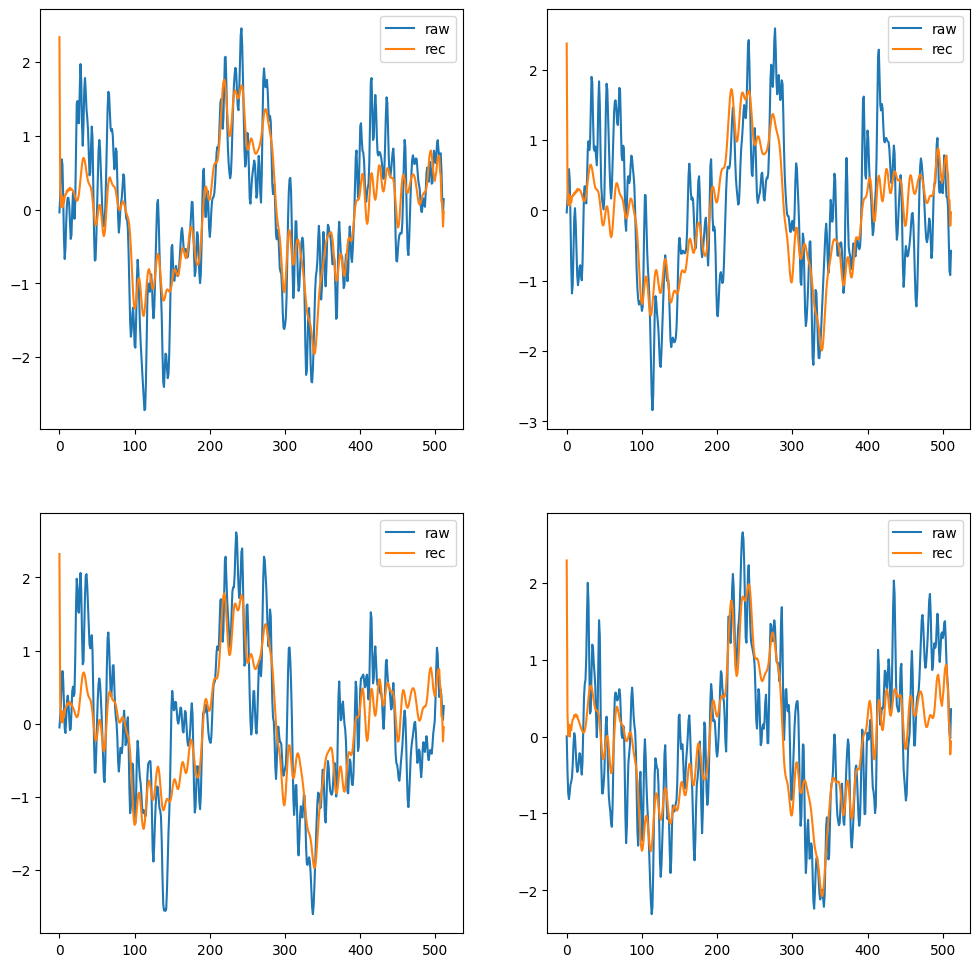

In [4]:
# Cada window_ds contém as janelas daquele arquivo/sujeito

with torch.no_grad():
    for window_ds in loaded_windows.datasets:
        for idx in range(len(window_ds)):
            x, y, _ = window_ds[idx]
            
            # CORREÇÃO: Normaliza o sinal por canal (Z-score) para adequar à faixa esperada pelo modelo
            x = (x - x.mean(axis=-1, keepdims=True)) / (x.std(axis=-1, keepdims=True) + 1e-6)
            # Adiciona dimensão de batch se necessário: [Channels, Time] -> [1, Channels, Time]
            inputs = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
            # Pega o ch_pos original [64, 3], adiciona o batch -> [1, 64, 3]
            pos_3d = torch.tensor(window_ds.ch_pos, dtype=torch.float32).unsqueeze(0).to(device)
            # Cria um tensor de zeros para as 3 dimensões faltantes [1, 64, 3] e concatena na última dimensão (dim=-1)
            pos = torch.cat([pos_3d, torch.zeros_like(pos_3d)], dim=-1)
            # Sensor type: 0 = EEG
            sensor_type = torch.zeros((1, x.shape[0]), dtype=torch.long).to(device)

            # convert into token sequences
            # input will be split into 2s segments(zero padded if not enough), and processed by tokenizer in parallel
            # 2s segments will output 8 token
            # overlap_ratio could define the overlap between segments
            features,indices=tokenizer.tokenize(inputs,pos,sensor_type,overlap_ratio=0.0)
            # Batch n_neuro=16 n_token n_dim
            print(f'features:{features.shape}')
            # the indice of codebook(which we use as pseudo label in stage 2)
            # Batch n_neuro=16 n_token n_codebook_layer
            print(f'indices:{indices.shape}')

            # reconstruction
            output_dict=tokenizer.visualize(inputs,pos,sensor_type)
            raw=rearrange(output_dict['x'], "... D -> (...) D").cpu()
            rec=rearrange(output_dict['x_rec'], "... D -> (...) D").cpu()
            random_select_indices = torch.randperm(raw.shape[0])[:4]
            # randomly choose some to show
            plt.figure(figsize=(12, 12))
            for i in range(4):
                plt.subplot(2, 2, i + 1)
                plt.plot(raw[random_select_indices[i]], label="raw")
                plt.plot(rec[random_select_indices[i]], label="rec")
                plt.legend()
            break # Carrega apenas 1 janela...
        break # Carrega apenas 1 janela...



# Base model

6 coordinates for pos -> x,y,z,theta,phi,radius??? I dont know!

x: B C T

pos: B C 6

sensor_type: B C

In [4]:
# 2. Configurar o dispositivo e carregar o BrainOmni pré-treinado
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_brainomni('ckpt_collection/base') # Inicialize ou carregue o checkpoint do BrainOmni
model.to(device)
model.eval()

/home/arielalves/BrainOmni/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


BrainOmni(
  (tokenizer): BrainTokenizer(
    (sensor_embed): BrainSensorModule(
      (sensor_embedding_layer): Embedding(3, 256)
      (pos_embedding_layer): Sequential(
        (0): Linear(in_features=6, out_features=128, bias=True)
        (1): SELU()
        (2): Linear(in_features=128, out_features=256, bias=True)
      )
      (aggregate_mlp): FeedForward(
        (layer): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): SELU()
          (2): Linear(in_features=1024, out_features=256, bias=True)
          (3): Identity()
        )
      )
      (norm): RMSNorm()
    )
    (encoder): BrainTokenizerEncoder(
      (seanet_encoder): SEANetEncoder(
        (model): Sequential(
          (0): SConv1d(
            (conv): NormConv1d(
              (conv): Conv1d(1, 32, kernel_size=(5,), stride=(1,))
              (norm): Identity()
            )
          )
          (1): SEANetResnetBlock(
            (block): Sequential(
              (0

## Opção A: UMAP de cada janela individual

Recomendado para ver a variabilidade temporal de cada sujeito.

In [ ]:
latent_outputs = []

with torch.no_grad():
    for dataset_idx, window_ds in enumerate(loaded_windows.datasets):
        pos_3d = torch.tensor(window_ds.ch_pos, dtype=torch.float32).unsqueeze(0).to(device)
        pos = torch.cat([pos_3d, torch.zeros_like(pos_3d)], dim=-1)
        
        print(f"\nGenerating latent space for subject {dataset_idx+1}/{len(loaded_windows.datasets)}\n")
        for idx in range(len(window_ds)):
            x, y, _ = window_ds[idx]
            
            x = (x - x.mean(axis=-1, keepdims=True)) / (x.std(axis=-1, keepdims=True) + 1e-6)
            inputs = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
            sensor_type = torch.zeros((1, x.shape[0]), dtype=torch.long).to(device)

            latent_space = model.encode(inputs, pos, sensor_type) # Ex: [1, 16, 512] ou [1, 1, 16, 512]
            
            # Achata todas as dimensões exceto o batch/primeira, transformando em um vetor 1D por janela
            latent_vector = latent_space.reshape(latent_space.shape[0], -1) # [1, Total_Features]
            latent_outputs.append(latent_vector.cpu())

            if(not idx%500):
                print(f"{idx+1}/{len(window_ds)}")

In [14]:
print(latent_outputs[0].shape)

torch.Size([1, 131072])


In [ ]:
# Concatena todas as janelas de todos os sujeitos em uma única matriz 2D: [1876, Total_Features]
final_features = torch.cat(latent_outputs, dim=0).numpy()
print("Formato final para o UMAP (por janelas):", final_features.shape)

In [ ]:
import gen_umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar e rodar o UMAP na matriz de características dos indivíduos
# (Certifique-se de que final_features é um array numpy com shape [N_indivíduos, Dimensão_Latente])
reducer = gen_umap.UMAP(
    n_neighbors=min(5, len(final_features) - 1), # Ajuste o n_neighbors se tiver poucos sujeitos
    min_dist=0.1, 
    metric='cosine', 
    random_state=42
)
embedding = reducer.fit_transform(final_features)

# 2. Plotar o gráfico 2D do UMAP
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1],
    # hue=subject_labels, # Opcional: passe uma lista com os rótulos/classes dos sujeitos se tiver
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.title('UMAP - Espaço Latente por Indivíduo (BrainOmni)', fontsize=14)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Opção B: Média estrita por indivíduo

Resume todas as janelas em um único vetor.

In [ ]:
subject_embeddings = []

with torch.no_grad():
    for dataset_idx, window_ds in enumerate(loaded_windows.datasets):
        # Pega o ch_pos original [64, 3], adiciona o batch -> [1, 64, 3]
        pos_3d = torch.tensor(window_ds.ch_pos, dtype=torch.float32).unsqueeze(0).to(device)
        # Cria um tensor de zeros para as 3 dimensões faltantes [1, 64, 3] e concatena na última dimensão (dim=-1)
        pos = torch.cat([pos_3d, torch.zeros_like(pos_3d)], dim=-1)
        
        print(f"\nGenerating latent space for subject {dataset_idx+1}/{len(loaded_windows.datasets)}\n")
        subject_windows = []
        for idx in range(len(window_ds)):
            x, y, _ = window_ds[idx]
            # CORREÇÃO: Normaliza o sinal por canal (Z-score) para adequar à faixa esperada pelo modelo
            x = (x - x.mean(axis=-1, keepdims=True)) / (x.std(axis=-1, keepdims=True) + 1e-6)
            # Adiciona dimensão de batch se necessário: [Channels, Time] -> [1, Channels, Time]
            inputs = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
            # Sensor type: 0 = EEG
            sensor_type = torch.zeros((1, x.shape[0]), dtype=torch.long).to(device)

            # Extrai apenas a saída do espaço latente (embeddings/tokens)
            # (O nome do método de extração pode variar dependendo da API do BrainOmni, ex: model.encode(inputs))
            latent_space = model.encode(inputs, pos, sensor_type)
            subject_windows.append(latent_space.cpu())

            if(not idx%500):
                print(f"{idx+1}/{len(window_ds)}")

        # Concatena as janelas DESTE sujeito específico e tira a média global
        subject_tensor = torch.cat(subject_windows, dim=0).mean(dim=[0, 1]) # Resulta em um vetor 1D de características
        subject_embeddings.append(subject_tensor)

In [25]:
# Matriz final com uma linha por indivíduo
final_features = torch.stack(subject_embeddings)

batch_size = final_features.size(0)
final_features = final_features.reshape(batch_size, -1)

print("Formato final para o UMAP (por indivíduo):", final_features.shape)

Formato final para o UMAP (por indivíduo): torch.Size([50, 8192])


/home/arielalves/BrainOmni/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_2493626/1515431770.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


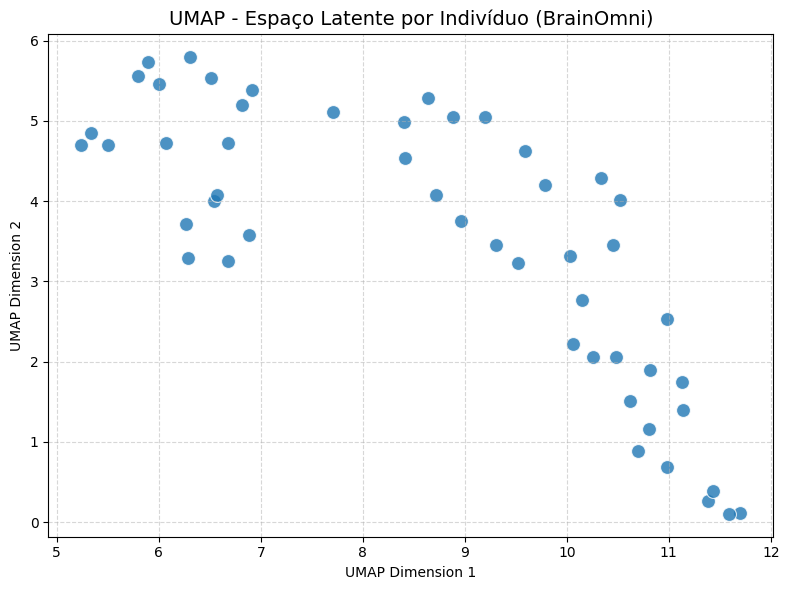

In [ ]:
import gen_umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar e rodar o UMAP na matriz de características dos indivíduos
# (Certifique-se de que final_features é um array numpy com shape [N_indivíduos, Dimensão_Latente])
reducer = gen_umap.UMAP(
    n_neighbors=min(5, len(final_features) - 1), # Ajuste o n_neighbors se tiver poucos sujeitos
    min_dist=0.1, 
    metric='cosine', 
    random_state=42
)
embedding = reducer.fit_transform(final_features)

# 2. Plotar o gráfico 2D do UMAP
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1],
    # hue=subject_labels, # Opcional: passe uma lista com os rótulos/classes dos sujeitos se tiver
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.title('UMAP - Espaço Latente por Indivíduo (BrainOmni)', fontsize=14)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()